In [13]:

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import gc
import pickle
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed
from PIL import Image
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm
from transformers import AutoModel, AutoModelForImageTextToText, AutoProcessor

import os
os.environ['CUDA_VISIBLE_DEVICES'] = "2"

In [14]:
# Constants.

DATA_CSV = Path("artifacts/processed_data/chexpertplus_frontal_5labels.csv")
RESULTS_DIR = Path("artifacts/results")
PROBES_DIR = Path("artifacts/probes")
PLOTS_DIR = Path("artifacts/plots")

METRICS_CSV = RESULTS_DIR / "experiment_metrics.csv"
YES_NO_CSV = RESULTS_DIR / "experiment_yes_no_scores.csv"

MEDSIGLIP_MODEL_ID = "google/medsiglip-448"
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"
MODEL_DTYPE = torch.bfloat16
FEATURE_DTYPE = np.float32

IMAGE_LOAD_NUM_WORKERS = 4
MEDSIGLIP_BATCH_SIZE = 512
MEDGEMMA_BATCH_SIZE = 24
PROBE_PARALLEL_JOBS = 16
PROBE_INNER_NUM_THREADS = 8
MAX_ITER = 2000
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

TARGET_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion",
]

for folder in [RESULTS_DIR, PROBES_DIR, PLOTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


In [15]:
# Load the processed CheXpert+ manifest.

df = pd.read_csv(DATA_CSV)
labels = (df[TARGET_LABELS].to_numpy() == 1).astype(np.int8)
train_idx = np.where(df["probe_split"].to_numpy() == "train")[0]
test_idx = np.where(df["probe_split"].to_numpy() == "test")[0]
image_paths = df["image_path"].tolist()

print("rows", len(df))
print("train", len(train_idx), "test", len(test_idx))
display(pd.DataFrame({
    "label": TARGET_LABELS,
    "train_positive_rate": labels[train_idx].mean(axis=0),
    "test_positive_rate": labels[test_idx].mean(axis=0),
}))


rows 25000
train 20000 test 5000


,label,train_positive_rate,test_positive_rate
0,Atelectasis,0.30930,0.3044
1,Cardiomegaly,0.22200,0.2196
2,Consolidation,0.17995,0.1752
3,Edema,0.29075,0.2754
4,Pleural Effusion,0.47520,0.4572


In [16]:
# Minimal helpers.

def slug(text):
    return re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")


def load_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB").copy()


def fit_probe(feature_matrix, layer, label, prompt_order, condition, feature_name):
    label_i = TARGET_LABELS.index(label)
    x = feature_matrix if layer is None else feature_matrix[:, layer, :]
    x_train = x[train_idx].astype(np.float32, copy=False)
    x_test = x[test_idx].astype(np.float32, copy=False)
    y_train = labels[train_idx, label_i]
    y_test = labels[test_idx, label_i]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, solver="lbfgs", max_iter=MAX_ITER, random_state=RANDOM_STATE),
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        with threadpool_limits(limits=PROBE_INNER_NUM_THREADS):
            model.fit(x_train, y_train)

    layer_name = "layer_none" if layer is None else f"layer_{int(layer):02d}"
    model_path = PROBES_DIR / slug(prompt_order) / slug(label) / layer_name / f"{slug(feature_name)}.pkl"
    model_path.parent.mkdir(parents=True, exist_ok=True)
    with model_path.open("wb") as f:
        pickle.dump(model, f)

    scores = model.predict_proba(x_test)[:, 1]
    return {
        "prompt_order": prompt_order,
        "condition": condition,
        "feature": feature_name,
        "layer": layer,
        "label": label,
        "feature_dim": int(x_train.shape[1]),
        "positive_prevalence": float(y_test.mean()),
        "auroc": float(roc_auc_score(y_test, scores)),
        "auprc": float(average_precision_score(y_test, scores)),
        "n_iter": int(model.named_steps["logisticregression"].n_iter_[0]),
        "model_path": str(model_path),
    }


In [17]:
# Cache images in CPU RAM once.

with ThreadPoolExecutor(max_workers=IMAGE_LOAD_NUM_WORKERS) as pool:
    images = list(tqdm(pool.map(load_rgb, image_paths), total=len(image_paths), desc="Load images"))

print("cached images", len(images))


Load images: 100%|██████████| 25000/25000 [07:31<00:00, 55.33it/s]

cached images 25000


In [18]:
# Prepare output containers.

metric_rows = []
yes_no_rows = []


In [19]:
# Extract standalone MedSigLIP features and train baseline probes.

device = "cuda" if torch.cuda.is_available() else "cpu"
medsiglip_processor = AutoProcessor.from_pretrained(MEDSIGLIP_MODEL_ID)
medsiglip_model = AutoModel.from_pretrained(MEDSIGLIP_MODEL_ID, dtype=MODEL_DTYPE).to(device).eval()
medsiglip_dim = medsiglip_model.config.vision_config.hidden_size
medsiglip_features = np.empty((len(df), medsiglip_dim), dtype=FEATURE_DTYPE)

for start in tqdm(range(0, len(images), MEDSIGLIP_BATCH_SIZE), desc="MedSigLIP"):
    end = min(start + MEDSIGLIP_BATCH_SIZE, len(images))
    inputs = medsiglip_processor(images=images[start:end], return_tensors="pt")
    inputs = {
        k: v.to(device=device, dtype=MODEL_DTYPE) if v.is_floating_point() else v.to(device=device)
        for k, v in inputs.items()
    }
    with torch.inference_mode():
        outputs = medsiglip_model.get_image_features(**inputs)
        emb = outputs.pooler_output if hasattr(outputs, "pooler_output") else outputs
        emb = emb / emb.norm(p=2, dim=-1, keepdim=True)
    medsiglip_features[start:end] = emb.float().cpu().numpy().astype(FEATURE_DTYPE)

jobs = [(None, label) for label in TARGET_LABELS]
metric_rows.extend(Parallel(n_jobs=PROBE_PARALLEL_JOBS, prefer="threads")(
    delayed(fit_probe)(medsiglip_features, layer, label, "baseline", "medsiglip_standalone", "medsiglip_standalone")
    for layer, label in tqdm(jobs, desc="MedSigLIP probes")
))

del medsiglip_model, medsiglip_processor, medsiglip_features
gc.collect()
torch.cuda.empty_cache()


Loading weights:  86%|████████▌ | 761/888 [00:02<00:00, 431.22it/s]

MedSigLIP probes: 100%|██████████| 5/5 [00:00<00:00, 13971.70it/s]


In [20]:
# Load MedGemma and process images once with the MedGemma image processor.

medgemma_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)
medgemma_model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    dtype=MODEL_DTYPE,
    device_map="auto",
).eval()

model_device = next(medgemma_model.parameters()).device
num_layers = medgemma_model.config.text_config.num_hidden_layers
hidden_size = medgemma_model.config.text_config.hidden_size
image_token_id = getattr(medgemma_model.config, "image_token_id", None)
if image_token_id is None:
    image_token_id = getattr(medgemma_model.config, "image_token_index")

pixel_chunks = []
for start in tqdm(range(0, len(images), MEDGEMMA_BATCH_SIZE), desc="MedGemma image processor"):
    end = min(start + MEDGEMMA_BATCH_SIZE, len(images))
    pixel_inputs = medgemma_processor.image_processor(images=images[start:end], return_tensors="pt", do_pan_and_scan=False)
    pixel_chunks.append(pixel_inputs["pixel_values"].to(dtype=MODEL_DTYPE, device="cpu"))
medgemma_pixel_values = torch.cat(pixel_chunks, dim=0)
del pixel_chunks

print("num_layers", num_layers)
print("hidden_size", hidden_size)
print("image_token_id", image_token_id)
print("cached pixel_values", tuple(medgemma_pixel_values.shape), medgemma_pixel_values.dtype)


MedGemma image processor:   4%|▍         | 45/1042 [00:31<10:39,  1.56it/s]

MedGemma image processor: 100%|██████████| 1042/1042 [21:29<00:00,  1.24s/it]


num_layers 34
hidden_size 2560
image_token_id 262144
cached pixel_values (25000, 3, 896, 896) torch.bfloat16


In [21]:
# Prompt/token helpers kept here because the image token expansion must match Gemma 3 processing.

def prompt_text(prompt_order, label):
    question = f"Question: Is there {label.lower()} in this image? Answer yes or no."
    image_item = {"type": "image"}
    if prompt_order == "image_first":
        content = [image_item, {"type": "text", "text": f"\n{question}\nAnswer: "}]
    else:
        content = [{"type": "text", "text": f"{question}\n"}, image_item, {"type": "text", "text": "\nAnswer: "}]
    messages = [{"role": "user", "content": content}]
    text = medgemma_processor.apply_chat_template(messages, add_generation_prompt=False, tokenize=False)
    if isinstance(text, list):
        text = text[0]
    return text.replace(medgemma_processor.boi_token, medgemma_processor.full_image_sequence)


def tokenize_prompt(prompt_order, label, batch_size):
    inputs = medgemma_processor.tokenizer(
        [prompt_text(prompt_order, label)] * batch_size,
        return_tensors="pt",
        padding=True,
    )

    if hasattr(medgemma_processor, "create_mm_token_type_ids"):
        token_type_ids = medgemma_processor.create_mm_token_type_ids(inputs["input_ids"])
        if not torch.is_tensor(token_type_ids):
            token_type_ids = torch.tensor(token_type_ids)
        inputs["token_type_ids"] = token_type_ids

    return inputs

check_inputs = tokenize_prompt("image_first", TARGET_LABELS[0], 1)
print("image token count", int(check_inputs["input_ids"].eq(image_token_id).sum().item()))

YES_TOKEN_ID = medgemma_processor.tokenizer("yes", add_special_tokens=False).input_ids[0]
NO_TOKEN_ID = medgemma_processor.tokenizer("no", add_special_tokens=False).input_ids[0]


image token count 256


In [22]:
# Run MedGemma prompts, train probes, and collect yes/no scores.

for prompt_order in ["image_first", "text_first"]:
    for label in TARGET_LABELS:
        print(prompt_order, label)

        # Extract each prompt-order/label block independently. This is slightly redundant for image_first,
        # but it keeps the experiment symmetric and lets us see whether prompt condition changes matter.
        predecoder_features = np.empty((len(df), hidden_size), dtype=FEATURE_DTYPE)
        layer_mean_features = np.empty((len(df), num_layers, hidden_size), dtype=FEATURE_DTYPE)
        layer_last_features = np.empty((len(df), num_layers, hidden_size), dtype=FEATURE_DTYPE)
        final_prompt_features = np.empty((len(df), num_layers, hidden_size), dtype=FEATURE_DTYPE)
        yes_logprob = np.empty(len(df), dtype=np.float32)
        no_logprob = np.empty(len(df), dtype=np.float32)

        for start in tqdm(range(0, len(df), MEDGEMMA_BATCH_SIZE), desc=f"{prompt_order} {label}"):
            end = min(start + MEDGEMMA_BATCH_SIZE, len(df))
            batch_size = end - start
            inputs = tokenize_prompt(prompt_order, label, batch_size)
            inputs["pixel_values"] = medgemma_pixel_values[start:end]
            inputs = {
                k: v.to(device=model_device, dtype=MODEL_DTYPE) if v.is_floating_point() else v.to(device=model_device)
                for k, v in inputs.items()
            }

            with torch.inference_mode():
                outputs = medgemma_model(
                    **inputs,
                    output_hidden_states=True,
                    use_cache=False,
                    logits_to_keep=1,
                    return_dict=True,
                )

            predecoder_features[start:end] = outputs.image_hidden_states.float().mean(dim=1).cpu().numpy().astype(FEATURE_DTYPE)

            log_probs = torch.log_softmax(outputs.logits[:, -1, :].float(), dim=-1)
            yes_logprob[start:end] = log_probs[:, YES_TOKEN_ID].cpu().numpy()
            no_logprob[start:end] = log_probs[:, NO_TOKEN_ID].cpu().numpy()

            image_mask = inputs["input_ids"].eq(image_token_id)
            image_token_count = int(image_mask.sum(dim=1)[0].item())
            last_positions = inputs["attention_mask"].sum(dim=1) - 1
            batch_arange = torch.arange(batch_size, device=model_device)

            for layer_i, hidden in enumerate(outputs.hidden_states[1:]):
                image_hidden = hidden[image_mask].reshape(batch_size, image_token_count, hidden_size).float()
                layer_mean_features[start:end, layer_i] = image_hidden.mean(dim=1).cpu().numpy().astype(FEATURE_DTYPE)
                layer_last_features[start:end, layer_i] = image_hidden[:, -1].cpu().numpy().astype(FEATURE_DTYPE)
                final_prompt_features[start:end, layer_i] = hidden[batch_arange, last_positions].float().cpu().numpy().astype(FEATURE_DTYPE)

            del outputs, inputs

        metric_rows.append(
            fit_probe(predecoder_features, None, label, prompt_order, label, "medgemma_pre_decoder_mean_image_token")
        )

        for feature_name, feature_matrix in [
            ("medgemma_layer_mean_image_token", layer_mean_features),
            ("medgemma_layer_last_image_token", layer_last_features),
        ]:
            jobs = [(layer, label) for layer in range(num_layers)]
            metric_rows.extend(Parallel(n_jobs=PROBE_PARALLEL_JOBS, prefer="threads")(
                delayed(fit_probe)(feature_matrix, layer, target_label, prompt_order, label, feature_name)
                for layer, target_label in tqdm(jobs, desc=f"{feature_name} probes")
            ))

        jobs = [(layer, label) for layer in range(num_layers)]
        metric_rows.extend(Parallel(n_jobs=PROBE_PARALLEL_JOBS, prefer="threads")(
            delayed(fit_probe)(final_prompt_features, layer, target_label, prompt_order, label, "medgemma_layer_final_prompt_token")
            for layer, target_label in tqdm(jobs, desc="final prompt token probes")
        ))

        label_i = TARGET_LABELS.index(label)
        score = yes_logprob - no_logprob
        yes_no_rows.append(pd.DataFrame({
            "study_id": df["study_id"],
            "subject_id": df["subject_id"],
            "dicom_id": df["dicom_id"],
            "probe_split": df["probe_split"],
            "prompt_order": prompt_order,
            "label": label,
            "y_true": labels[:, label_i],
            "logprob_yes": yes_logprob,
            "logprob_no": no_logprob,
            "score_yes_minus_no": score,
            "pred_yes": score > 0,
        }))
        metric_rows.append({
            "prompt_order": prompt_order,
            "condition": label,
            "feature": "medgemma_yes_no_logprob",
            "layer": None,
            "label": label,
            "feature_dim": 1,
            "positive_prevalence": float(labels[test_idx, label_i].mean()),
            "auroc": float(roc_auc_score(labels[test_idx, label_i], score[test_idx])),
            "auprc": float(average_precision_score(labels[test_idx, label_i], score[test_idx])),
            "n_iter": None,
            "model_path": "",
        })

        del predecoder_features, layer_mean_features, layer_last_features, final_prompt_features, yes_logprob, no_logprob
        gc.collect()
        torch.cuda.empty_cache()


image_first Atelectasis


image_first Atelectasis:   2%|▏         | 18/1042 [00:13<11:56,  1.43it/s]

final prompt token probes: 100%|██████████| 34/34 [01:17<00:00,  2.28s/it]


image_first Cardiomegaly


final prompt token probes: 100%|██████████| 34/34 [01:11<00:00,  2.09s/it]


...

final prompt token probes: 100%|██████████| 34/34 [01:06<00:00,  1.95s/it]


text_first Edema


final prompt token probes: 100%|██████████| 34/34 [01:27<00:00,  2.57s/it]


text_first Pleural Effusion


final prompt token probes: 100%|██████████| 34/34 [01:20<00:00,  2.38s/it]


In [23]:
# Save results.

metrics_df = pd.DataFrame(metric_rows)
metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")
metrics_df = metrics_df.sort_values(["prompt_order", "condition", "feature", "layer", "label"], na_position="first")
yes_no_df = pd.concat(yes_no_rows, ignore_index=True)

metrics_df.to_csv(METRICS_CSV, index=False)
yes_no_df.to_csv(YES_NO_CSV, index=False)

print("metrics rows", len(metrics_df))
print("yes/no rows", len(yes_no_df))
print("saved", METRICS_CSV)
print("saved", YES_NO_CSV)
print("saved probes to", PROBES_DIR)

display(metrics_df)
display(
    metrics_df
    .groupby(["prompt_order", "feature", "layer"], dropna=False, as_index=False)
    .agg(mean_auroc=("auroc", "mean"), mean_auprc=("auprc", "mean"))
    .sort_values("mean_auroc", ascending=False)
)


metrics rows 1045
yes/no rows 250000
saved artifacts/results/experiment_metrics.csv
saved artifacts/results/experiment_yes_no_scores.csv
saved probes to artifacts/probes


,prompt_order,condition,feature,layer,label,feature_dim,positive_prevalence,auroc,auprc,n_iter,model_path
0,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Atelectasis,1152,0.3044,0.668771,0.440765,1512.0,artifacts/probes/baseline/atelectasis/layer_no...
1,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Cardiomegaly,1152,0.2196,0.810684,0.561113,1234.0,artifacts/probes/baseline/cardiomegaly/layer_n...
2,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Consolidation,1152,0.1752,0.669918,0.282204,1326.0,artifacts/probes/baseline/consolidation/layer_...
3,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Edema,1152,0.2754,0.795775,0.568492,1407.0,artifacts/probes/baseline/edema/layer_none/med...
4,baseline,medsiglip_standalone,medsiglip_standalone,NaN,Pleural Effusion,1152,0.4572,0.849411,0.824788,1325.0,artifacts/probes/baseline/pleural_effusion/lay...
...,...,...,...,...,...,...,...,...,...,...,...
973,text_first,Pleural Effusion,medgemma_layer_mean_image_token,31.0,Pleural Effusion,2560,0.4572,0.826178,0.800149,581.0,artifacts/probes/text_first/pleural_effusion/l...
974,text_first,Pleural Effusion,medgemma_layer_mean_image_token,32.0,Pleural Effusion,2560,0.4572,0.827977,0.803359,582.0,artifacts/probes/text_first/pleural_effusion/l...
975,text_first,Pleural Effusion,medgemma_layer_mean_image_token,33.0,Pleural Effusion,2560,0.4572,0.825981,0.799221,684.0,artifacts/probes/text_first/pleural_effusion/l...
941,text_first,Pleural Effusion,medgemma_pre_decoder_mean_image_token,NaN,Pleural Effusion,2560,0.4572,0.845599,0.820963,1371.0,artifacts/probes/text_first/pleural_effusion/l...


,prompt_order,feature,layer,mean_auroc,mean_auprc
0,baseline,medsiglip_standalone,NaN,0.758912,0.535472
207,text_first,medgemma_pre_decoder_mean_image_token,NaN,0.754607,0.530961
103,image_first,medgemma_pre_decoder_mean_image_token,NaN,0.754607,0.530961
69,image_first,medgemma_layer_mean_image_token,0.0,0.731352,0.503956
173,text_first,medgemma_layer_mean_image_token,0.0,0.731347,0.504062
...,...,...,...,...,...
61,image_first,medgemma_layer_last_image_token,26.0,0.661975,0.416236
59,image_first,medgemma_layer_last_image_token,24.0,0.661929,0.417403
60,image_first,medgemma_layer_last_image_token,25.0,0.661320,0.416717
68,image_first,medgemma_layer_last_image_token,33.0,0.661265,0.414852


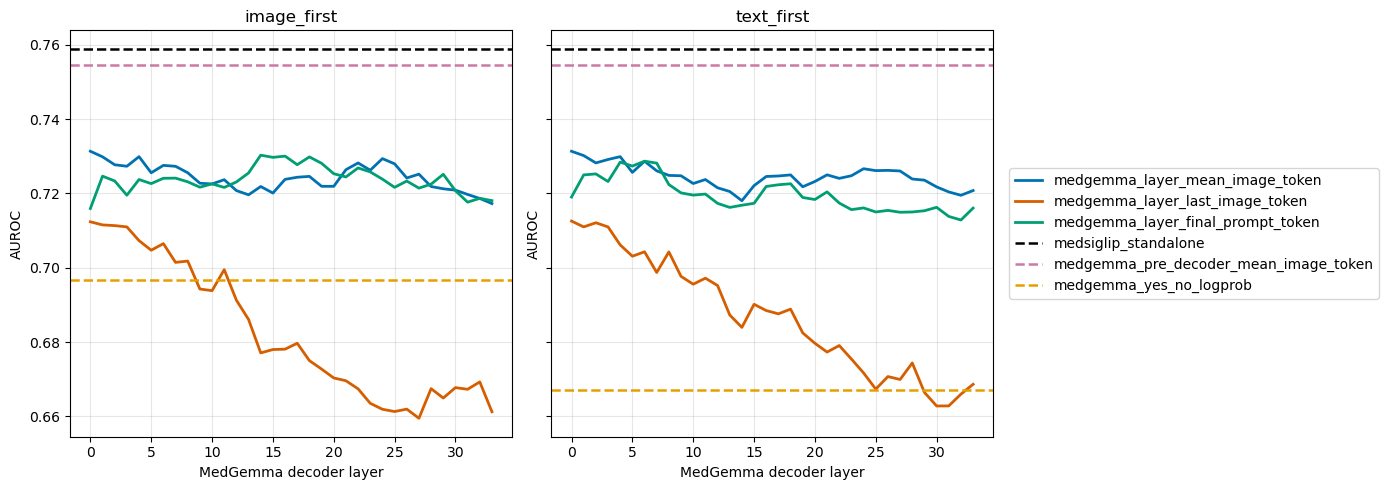

saved artifacts/plots/mean_auroc_over_layers.png


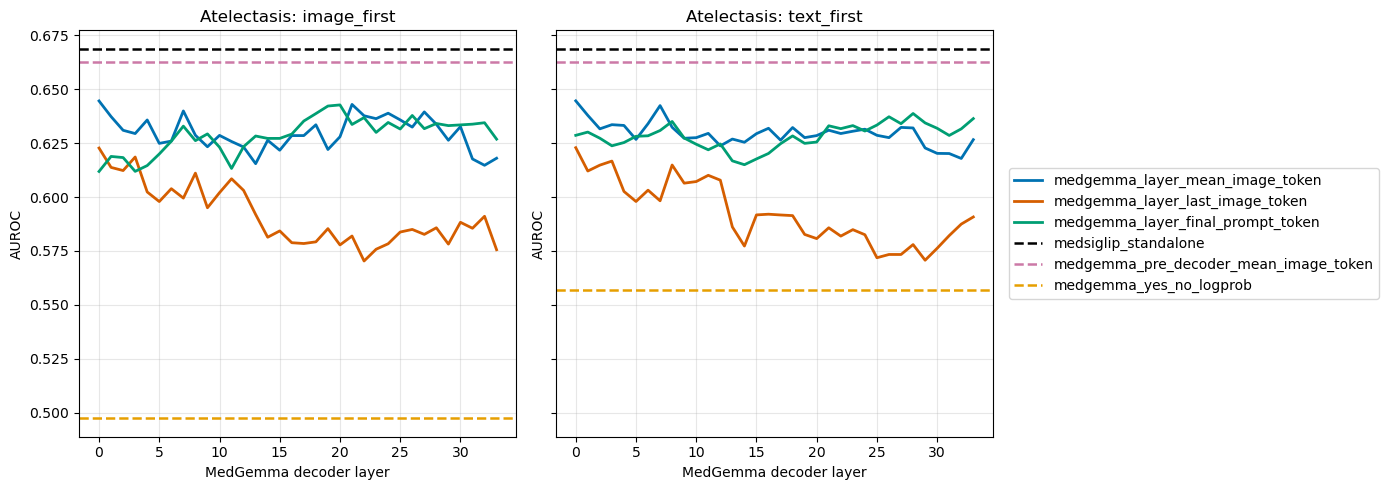

saved artifacts/plots/atelectasis_auroc_over_layers.png


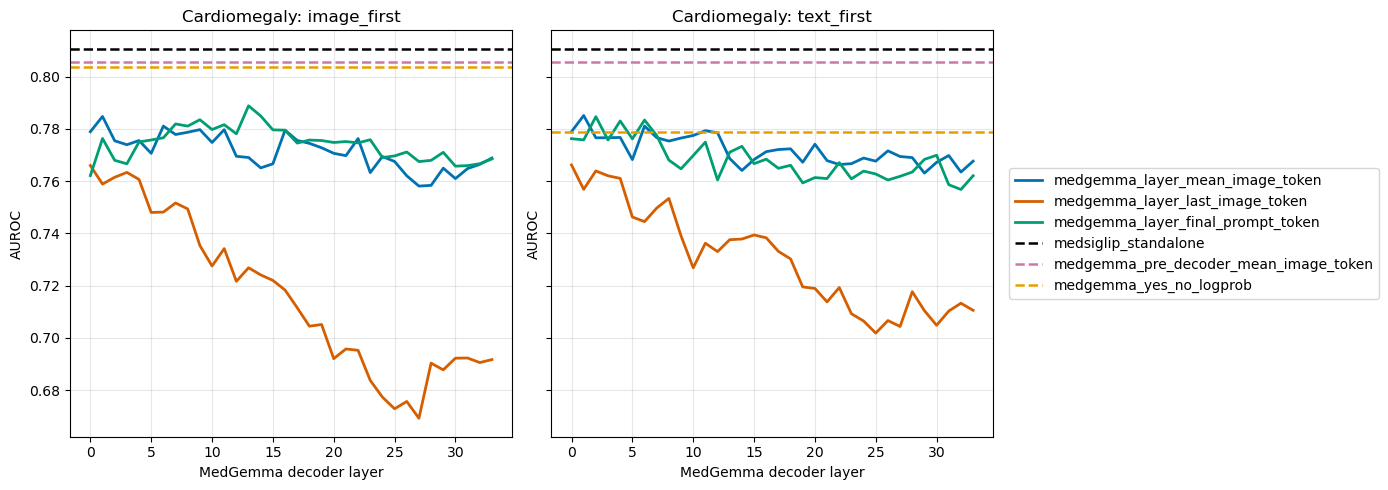

saved artifacts/plots/cardiomegaly_auroc_over_layers.png


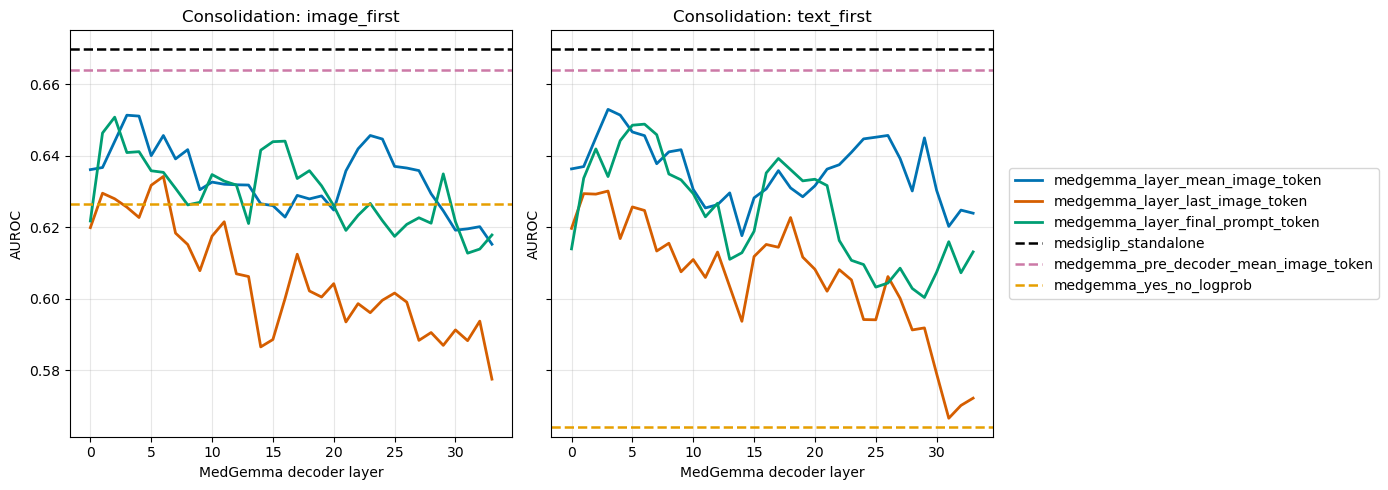

saved artifacts/plots/consolidation_auroc_over_layers.png


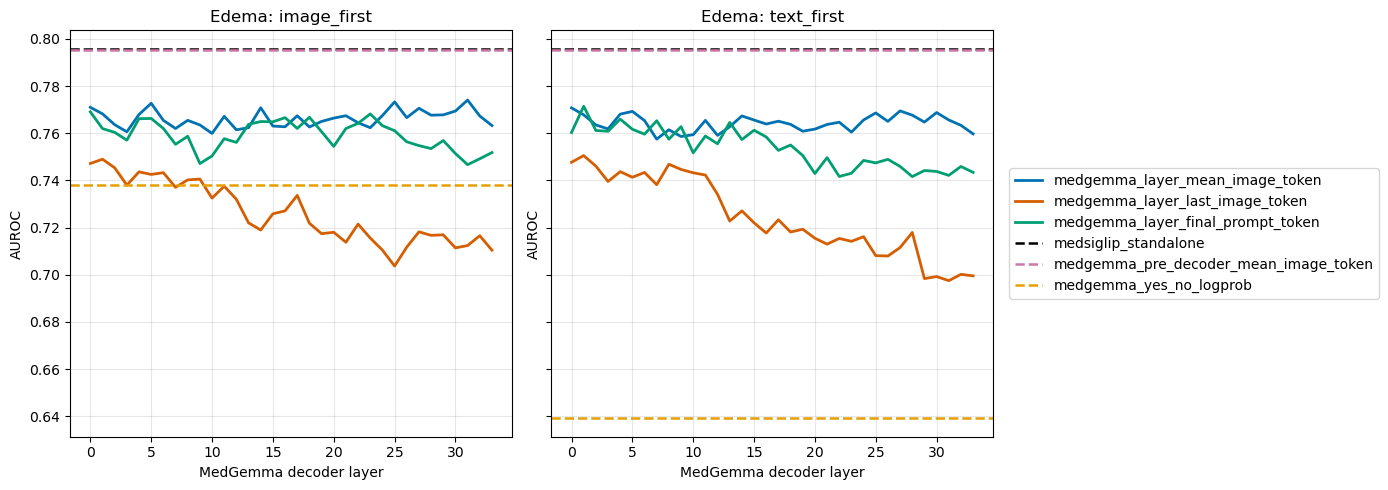

saved artifacts/plots/edema_auroc_over_layers.png


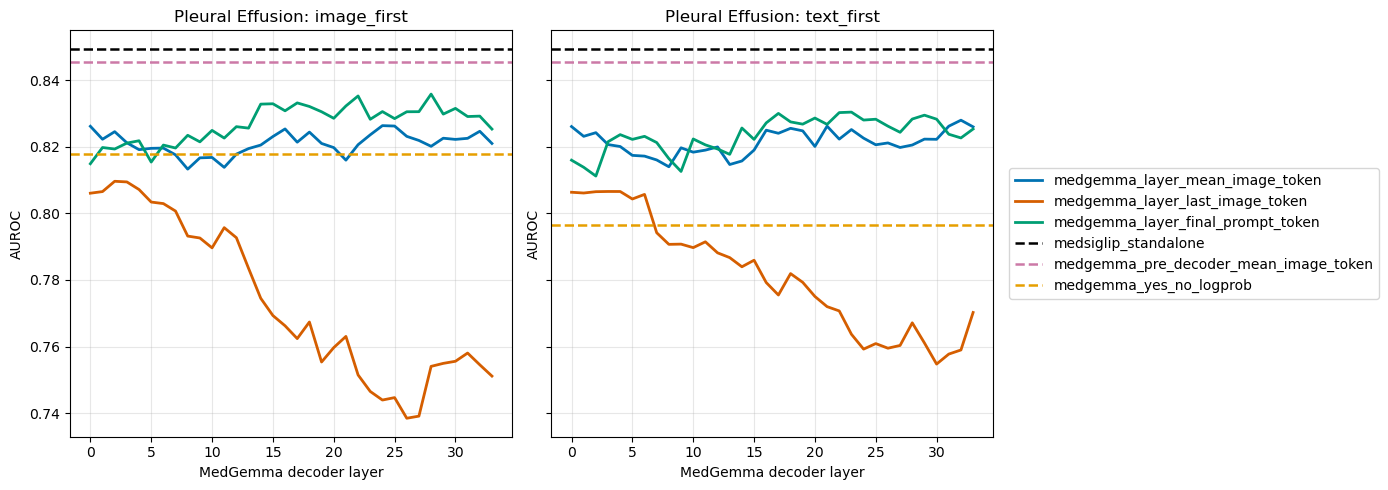

saved artifacts/plots/pleural_effusion_auroc_over_layers.png


In [24]:
metrics_df = pd.read_csv(METRICS_CSV)

layer_features = [
    "medgemma_layer_mean_image_token",
    "medgemma_layer_last_image_token",
    "medgemma_layer_final_prompt_token",
]
baseline_features = [
    "medsiglip_standalone",
]
feature_colors = {
    "medgemma_layer_mean_image_token": "#0072B2",
    "medgemma_layer_last_image_token": "#D55E00",
    "medgemma_layer_final_prompt_token": "#009E73",
    "medsiglip_standalone": "#000000",
    "medgemma_pre_decoder_mean_image_token": "#CC79A7",
    "medgemma_yes_no_logprob": "#E69F00",
}

for label in [None] + TARGET_LABELS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, prompt_order in zip(axes, ["image_first", "text_first"]):
        layer_df = metrics_df[metrics_df["prompt_order"] == prompt_order]
        baseline_df = metrics_df[metrics_df["prompt_order"] == "baseline"]
        if label is not None:
            layer_df = layer_df[layer_df["label"] == label]
            baseline_df = baseline_df[baseline_df["label"] == label]

        for feature_name in layer_features:
            sub = layer_df[layer_df["feature"] == feature_name]
            if sub.empty:
                continue
            if label is None:
                sub = sub.groupby("layer", as_index=False).agg(auroc=("auroc", "mean"))
            else:
                sub = sub.sort_values("layer")
            ax.plot(sub["layer"], sub["auroc"], color=feature_colors[feature_name], linewidth=2.0, label=feature_name)

        for feature_name in baseline_features:
            sub = baseline_df[baseline_df["feature"] == feature_name]
            if sub.empty:
                continue
            y = sub["auroc"].mean() if label is None else sub["auroc"].iloc[0]
            ax.axhline(y, color=feature_colors[feature_name], linestyle="--", linewidth=1.8, label=feature_name)

        sub = layer_df[layer_df["feature"] == "medgemma_pre_decoder_mean_image_token"]
        if not sub.empty:
            y = sub["auroc"].mean() if label is None else sub["auroc"].iloc[0]
            ax.axhline(y, color=feature_colors["medgemma_pre_decoder_mean_image_token"], linestyle="--", linewidth=1.8, label="medgemma_pre_decoder_mean_image_token")

        sub = layer_df[layer_df["feature"] == "medgemma_yes_no_logprob"]
        if not sub.empty:
            y = sub["auroc"].mean() if label is None else sub["auroc"].iloc[0]
            ax.axhline(y, color=feature_colors["medgemma_yes_no_logprob"], linestyle="--", linewidth=1.8, label="medgemma_yes_no_logprob")

        ax.set_title(prompt_order if label is None else f"{label}: {prompt_order}")
        ax.set_xlabel("MedGemma decoder layer")
        ax.set_ylabel("AUROC")
        ax.grid(True, alpha=0.3)

    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    if label is None:
        plot_path = PLOTS_DIR / "mean_auroc_over_layers.png"
    else:
        plot_path = PLOTS_DIR / f"{slug(label)}_auroc_over_layers.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print("saved", plot_path)
